In [ ]:
""" 
THIS DDIM VERSION 2
IT TRAINS OUR 100X300 IMAGES
THIS VERSIONS WORKS ON RESIZES
IMAGES INTO 96X296

[CHANGE THIS]

"""

' \nTHIS DDIM VERSION 2\nIT TRAINS OUR 100X300 IMAGES\nTHIS VERSIONS WORKS ON RESIZES\nIMAGES INTO 96X296\n\n[CHANGE THIS]\n\n'

In [2]:
""" ALL IMPORTS """
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'


import math
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfd

tf.config.optimizer.set_jit(False)

#%pip install --upgrade tensorflow==2.15
#%pip install --upgrade keras==3.3.3
    # only these versions of tensorflow and keras will work
    # to run in this current version of the notebook

import keras
from keras import layers
from keras import ops

""" CHANGE THE FOLDER NAME HERE """
folder_path = "[INSERT NAME HERE]"
# create the folder if it does not exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

""" 
CONFIGURATIONS WITHIN THIS CELL WORKS WITH LOCAL GPU
"""

' \nCONFIGURATIONS WITHIN THIS CELL WORKS WITH LOCAL GPU\n'

In [3]:
""" 
ENSURE WE ARE USING THE CORRECT VERSION 
ONLY KERAS 3.3.3 AND TENSORFLOW 2.15 HAS 
BEEN PROVEN TO WORK WITH THIS SCRIPT
"""
print(keras.__version__)
print(tf.__version__)

3.6.0
2.17.0


Found 2348 files belonging to 1 classes.
Using 1879 files for training.


I0000 00:00:1729366750.171203  186194 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1729366750.214634  186194 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1729366750.214824  186194 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1729366750.215730  186194 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Found 2348 files belonging to 1 classes.
Using 469 files for validation.


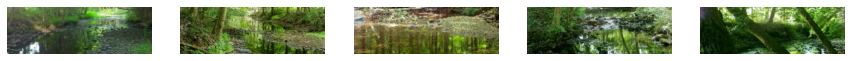

In [4]:
""" PARAMETERS FOR PREPARE DATASET """
image_size = (96, 296)           # (height, width)
img_folder_name = "flow_300_100" # must be in cwd

seed = 42
validation_split = 0.2
batch_size = 12
dataset_repetitions = 5

# for the time being I will add padding
# to the images, I will modify it in the 
# future
pad_to_aspect_ratio = False
crop_to_aspect_ratio = True     # just in case

""" LOAD DATASET """
def load_dataset(): 
    cwd = os.getcwd()
    img_dir = os.path.join(cwd, img_folder_name)
    
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        img_dir, 
        validation_split = validation_split,
        subset="training", 
        seed = seed,
        image_size = (image_size[0], image_size[1]),  
        batch_size = None,
        shuffle = True,
        crop_to_aspect_ratio = crop_to_aspect_ratio,
        pad_to_aspect_ratio = pad_to_aspect_ratio,
        #labels = labels, 
        #label_mode = None
    )
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        img_dir, 
        validation_split = validation_split,
        subset="validation", 
        seed = seed,
        image_size = (image_size[0], image_size[1]), 
        batch_size = None,
        shuffle = True,
        crop_to_aspect_ratio = crop_to_aspect_ratio,
        pad_to_aspect_ratio = pad_to_aspect_ratio,
        #labels = labels, 
        #label_mode = None
    )
    return train_ds, val_ds

""" PREPARE DATASET """
def prepare_dataset(train_ds, val_ds): 
    train_ds = (train_ds
        .map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE) # each dataset has the structure
        .cache()                                                   # (image, labels) when inputting to 
        .repeat(dataset_repetitions)                               # map
        .shuffle(10 * batch_size)
        .batch(batch_size, drop_remainder=True)
        .prefetch(buffer_size=tf.data.AUTOTUNE))
    val_ds = (val_ds
        .map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        .repeat(dataset_repetitions)
        .shuffle(10 * batch_size)
        .batch(batch_size, drop_remainder=True)
        .prefetch(buffer_size=tf.data.AUTOTUNE)) # THIS IS A PREFETCH DATASET
    return train_ds, val_ds

def normalize_image(images, _):    
    return tf.clip_by_value(images / 255, 0.0, 1.0)
    # clip pixel values to the range [0, 1]

""" PLOT THE IMAGES """
def plot_images(dataset, num_images=5):
    # Create an iterator to get images from the dataset
    iterator = iter(dataset)
    
    # Get the first batch of images
    images = next(iterator)

    # Plot the images
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        axes[i].imshow(images[i])
        axes[i].axis("off")
    plt.show()

train_dataset, val_dataset = load_dataset()
train_dataset, val_dataset = prepare_dataset(train_dataset, val_dataset)

# Plot a sample of images from the train dataset
plot_images(train_dataset)

In [5]:
"""
---KID Parameters---
KID = Kernel Inception Distance

Why KID? 
- KID is more suitable for small datasets 
- computationally lighter
- numerically more stable
- simpler to implement
"""

kid_image_size = 128      
plot_diffusion_steps = 20 # 100

"""
HIGH LEVEL SUMMARY

    - Extract features from real and generated images using a pretrained InceptionV3 model.
    - Compute polynomial kernels between these features.
    - Estimate the squared maximum mean discrepancy (MMD) using average kernel values.
    - Update the KID estimate based on real and generated features2.
"""
@keras.saving.register_keras_serializable()
class KID(keras.metrics.Metric): # inherits from Metrics class
    def __init__(self, name, **kwargs):
        super().__init__(name=name, **kwargs)

        self.kid_tracker = keras.metrics.Mean(name="kid_tracker")
            # mean metric to track the average KID across batches

        # a pretrained InceptionV3 is used without its classification layer
        # transform the pixel values to the 0-255 range, then use the same
        # preprocessing as during pretraining
        self.encoder = keras.Sequential(
            [
                ###CHANGED IMAGE SIZE HERE### 
                keras.Input(shape=(image_size[0], image_size[1], 3)), 
                layers.Rescaling(255.0), # the input images rescaled to the [0, 255] range, 
                layers.Resizing(height=kid_image_size, width=kid_image_size),    # resized to kid_image_size
                layers.Lambda(keras.applications.inception_v3.preprocess_input), # preprocessed as during InceptionV3
                keras.applications.InceptionV3(                                  # pretraining.
                    include_top=False,
                    input_shape=(kid_image_size, kid_image_size, 3),
                    weights="imagenet",
                ),
                layers.GlobalAveragePooling2D(),
            ],
            name="inception_encoder",
        )
            # InceptionV3 is a (CNN) architecture 
            # It is specifically designed for image classification tasks
            # it addressed overfitting by using parallel layers (Inception modules) with different filter sizes.

    def polynomial_kernel(self, features_1, features_2):
        feature_dimensions = ops.cast(ops.shape(features_1)[1], dtype="float32")
        return (
            features_1 @ ops.transpose(features_2) / feature_dimensions + 1.0
        ) ** 3.0
            # Computes a polynomial kernel between two sets of features.

    def update_state(self, real_images, generated_images, sample_weight=None):
        real_features = self.encoder(real_images, training=False)
        generated_features = self.encoder(generated_images, training=False)

        # compute polynomial kernels using the two sets of features
        kernel_real = self.polynomial_kernel(real_features, real_features)
        kernel_generated = self.polynomial_kernel(
            generated_features, generated_features
        )
        kernel_cross = self.polynomial_kernel(real_features, generated_features)

        # estimate the squared maximum mean discrepancy using the average kernel values
        batch_size = real_features.shape[0]
        batch_size_f = ops.cast(batch_size, dtype="float32")
        
        mean_kernel_real = ops.sum(kernel_real * (1.0 - ops.eye(batch_size))) / (
            batch_size_f * (batch_size_f - 1.0)
        )
        
        mean_kernel_generated = ops.sum(
            kernel_generated * (1.0 - ops.eye(batch_size))
        ) / (batch_size_f * (batch_size_f - 1.0))
        
        mean_kernel_cross = ops.mean(kernel_cross)
        
        kid = mean_kernel_real + mean_kernel_generated - 2.0 * mean_kernel_cross
        
        self.kid_tracker.update_state(kid)
            # updates the KID estimate based on real and generated features.

    def result(self):
        return self.kid_tracker.result()
            # returns the current KID estimate.

    def reset_state(self):
        self.kid_tracker.reset_state()
            # resets the KID tracker.
        

## Network architecture

Here we specify the architecture of the neural network that we will use for denoising. We
build a [U-Net](https://arxiv.org/abs/1505.04597) with identical input and output
dimensions. U-Net is a popular semantic segmentation architecture, whose main idea is
that it progressively downsamples and then upsamples its input image, and adds skip
connections between layers having the same resolution. These help with gradient flow and
avoid introducing a representation bottleneck, unlike usual
[autoencoders](https://www.deeplearningbook.org/contents/autoencoders.html). Based on
this, one can view
[diffusion models as denoising autoencoders](https://benanne.github.io/2022/01/31/diffusion.html)
without a bottleneck.

The network takes two inputs, the noisy images and the variances of their noise
components. The latter is required since denoising a signal requires different operations
at different levels of noise. We transform the noise variances using sinusoidal
embeddings, similarly to positional encodings used both in
[transformers](https://arxiv.org/abs/1706.03762) and
[NeRF](https://arxiv.org/abs/2003.08934). This helps the network to be
[highly sensitive](https://arxiv.org/abs/2006.10739) to the noise level, which is
crucial for good performance. We implement sinusoidal embeddings using a
[Lambda layer](https://keras.io/api/layers/core_layers/lambda/).

Some other considerations:

* We build the network using the
[Keras Functional API](https://keras.io/guides/functional_api/), and use
[closures](https://twitter.com/fchollet/status/1441927912836321280) to build blocks of
layers in a consistent style.
* [Diffusion models](https://arxiv.org/abs/2006.11239) embed the index of the timestep of
the diffusion process instead of the noise variance, while
[score-based models (Table 1)](https://arxiv.org/abs/2206.00364)
usually use some function of the noise level. I
prefer the latter so that we can change the sampling schedule at inference time, without
retraining the network.
* [Diffusion models](https://arxiv.org/abs/2006.11239) input the embedding to each
convolution block separately. We only input it at the start of the network for
simplicity, which in my experience barely decreases performance, because the skip and
residual connections help the information propagate through the network properly.
* In the literature it is common to use
[attention layers](https://keras.io/api/layers/attention_layers/multi_head_attention/)
at lower resolutions for better global coherence. I omitted it for simplicity.
* We disable the learnable center and scale parameters of the batch normalization layers,
since the following convolution layers make them redundant.
* We initialize the last convolution's kernel to all zeros as a good practice, making the
network predict only zeros after initialization, which is the mean of its targets. This
will improve behaviour at the start of training and make the mean squared error loss
start at exactly 1.

In [6]:
"""
Creating a custom layer called Sinusoidal Embedding
to replace Lambda layers that were causing  errors 
(probably due to dependencies reasons)
"""
@keras.saving.register_keras_serializable()
class SinusoidalEmbedding(layers.Layer): 
    def __init__(self, embedding_dims, **kwargs):
        super(SinusoidalEmbedding, self).__init__(**kwargs) # sets up the layer by calling the superclass
        self.embedding_dims = embedding_dims

    def build(self, input_shape):
        """
        Taken from the local sinusoidal_embedding 
        Build method is called when building the layer
        """
        self.embedding_min_frequency = 1.0
        self.embedding_max_frequency = 1000.0  # You can adjust this value
        frequencies = tf.exp(
            tf.linspace(
                tf.math.log(self.embedding_min_frequency),
                tf.math.log(self.embedding_max_frequency),
                self.embedding_dims // 2,
            )
        )
        angular_speeds = 2.0 * tf.constant(math.pi) * frequencies
        self.angular_speeds = tf.cast(angular_speeds, dtype=tf.float32)
        """
        We compute the frequencies for the sinusoidal embeddings 
        using exponential and logarithmic operations.
        """

    def call(self, x):
        # Assuming x is a scalar (e.g., noise_variances)
        # call layer defines how the layer processes the input data
        embeddings = tf.concat(
            [tf.sin(self.angular_speeds * x), tf.cos(self.angular_speeds * x)], axis=-1
        )
        return embeddings
        """
        We compute the sinusoidal embeddings by concatenating sine
        and cosine functions of the angular speeds.
        The output embeddings contain both sine and cosine components.
        """

In [7]:
"""
HIGH LEVEL SUMMARY: 
This function defines a residual block for a neural network
Residual blocks are layers which outputs are added to a deeper
layer

    - It checks the input width (input_width) of the tensor x.
    - If the input width matches the specified width, it sets the residual to be the same as x.
    - Otherwise, it applies a 1x1 convolution (layers.Conv2D) to transform the input tensor to the desired width.
    - Next, it applies batch normalization (layers.BatchNormalization) and two 3x3 convolutions with ReLU activation
        (swish activation is used here).
    - Finally, it adds the residual tensor to the output tensor and returns it.

"""
@keras.saving.register_keras_serializable()
def ResidualBlock(width): # width specify the number of output channels
    def apply(x):
        input_width = x.shape[3]
        if input_width == width:
            residual = x # set residual to be the same as x if it matches
        else:
            residual = layers.Conv2D(width, kernel_size=1)(x) # set residual to the desired width
        x = layers.BatchNormalization(center=False, scale=False)(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same", activation="swish")(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same")(x)
        x = layers.Add()([x, residual])
        return x
    return apply

block_depth = 2

"""
HIGH LEVEL SUMMARY: 
This function defines a downsampling block that reduces the spatial dimensions of the input tensor.

    - It expects a tuple (x, skips) as input, where x is the input tensor, and skips is a list to 
        store intermediate tensors.
    - It repeatedly applies block_depth residual blocks to the input tensor.
    - After that, it performs average pooling (reducing spatial dimensions) on the output tensor.
    - The function returns the downsampled tensor.

"""
@keras.saving.register_keras_serializable()
def DownBlock(width, block_depth): 
    # width is number of output channels for the residual blocks
    # block_depth determines how many residual blocks are stacked in this 
        # downsampling block
    def apply(x):
        x, skips = x
        for _ in range(block_depth):
            x = ResidualBlock(width)(x)
            skips.append(x)
        x = layers.AveragePooling2D(pool_size=2)(x) 
            # average pooling reduces spatial dimensions
        return x
    return apply
        # returns the downsampled tensor

"""
HIGH LEVEL SUMMARY:
This function defines an upsampling block that increases the spatial dimensions of the input tensor.

        - It also expects a tuple (x, skips) as input.
        - It first performs upsampling using bilinear interpolation (layers.UpSampling2D).
        - Then, it concatenates the upsampled tensor with the last tensor stored in skips.
        - It applies block_depth residual blocks to the concatenated tensor.
        - The function returns the upsampled tensor.
        
"""
@keras.saving.register_keras_serializable()
def UpBlock(width, block_depth):
    # same parameters as downblock with width and block_depth
    def apply(x):
        x, skips = x
        x = layers.UpSampling2D(size=2, interpolation="bilinear")(x) # upsampling here
        for _ in range(block_depth):
            a = skips.pop()
            print("this is the concatenate (layer, skip):",  x, "and", a)
            x = layers.Concatenate()([x, a]) # concatenates the upsampled tensor with
            x = ResidualBlock(width)(x)                # the last tensor stored in skips (a stack)
        return x
    return apply
        # returns upsampled tensor

embedding_dims = 128


# The widths of each subsequent downsample blocks
#widths = [32, 64, 96, 128, 256] # there will be 5 downsample blocks (including the bottleneck) 
widths = [32, 64, 96, 128] 
#widths = [150, 300, 450, 600]
#widths = [128, 256, 384, 512]

"""
HIGH LEVEL SUMMARY: 

    - Creates U-Net Model
        - The model takes inputs [noisy_images, noise_variances] and produces the denoised output.
        - The model is named “residual_unet”.
    - Uses the few functions mentioned above
    - Check comments for more information

"""
@keras.saving.register_keras_serializable()
def get_network(image_size, widths, block_depth):
    noisy_images = keras.Input(shape=(image_size[0], image_size[1], 3)) # Input for noisy images
    noise_variances = keras.Input(shape=(1, 1, 1))                # Input for noise variances

    print("this is noisy images", noisy_images)

    sinusoidal_layer = SinusoidalEmbedding(embedding_dims) 
        # from our custom Sinusoidal Embeddig Layer 
    
    # Call the layer with your input (e.g., noise_variances)
    e = sinusoidal_layer(noise_variances)
    e = layers.UpSampling2D(size=image_size, interpolation="nearest")(e)
        # noise variances inputwidthed to sinusoidal layer
        # then to upsampling using nearest neighbor interpolation

    x = layers.Conv2D(widths[0], kernel_size=1)(noisy_images)
    x = layers.Concatenate()([x, e])
        # noisy images input into Conv2D 
        # output is concatenated with e

    skips = [] # skip is a list
    for width in widths[:-1]:
        print("this is downblock width", width)
        x = DownBlock(width, block_depth)([x, skips])
            # series of downblocks are applied to the concatenated features
            # each downblock reduces spatial resolution and increases the number
                # of filters
        print("this is downblock shape", x)

    for _ in range(block_depth):
        print("this is the bottleneck width" , widths[-1])
        x = ResidualBlock(widths[-1])(x)
            # stack of residual blocks is applied
        print("this is bottleneck shape", x)

    for width in reversed(widths[:-1]):
        print("this is upblock width", width)
        x = UpBlock(width, block_depth)([x, skips])
            # each block upsamples the features and reduces the number 
                # of filters
        print("this is upblock shape", x)

    x = layers.Conv2D(3, kernel_size=1, kernel_initializer="zeros")(x)
        # final convolution, 1x1 convolution with 3 channels (RGB) is applied to the output

    return keras.Model([noisy_images, noise_variances], x, name="residual_unet")

# network = get_network(image_size, widths, block_depth) # obtaining the U-NET

This showcases the power of the Functional API. Note how we built a relatively complex
U-Net with skip connections, residual blocks, multiple inputs, and sinusoidal embeddings
in 80 lines of code!

In [8]:
# number of diffusion steps for calculating KID
kid_diffusion_steps = 5

# sampling
min_signal_rate = 0.1
max_signal_rate = 0.5

# exponential moving average weight used during evaluation
ema = 0.999

"""
HIGH LEVEL SUMMARY: 

    Few important functions to know
        - compile
        - generate 
        - train_step

"""
@keras.saving.register_keras_serializable()
class DiffusionModel(keras.Model): 
            # inherits from Model
    def __init__(self, image_size, widths, block_depth):
            # parameters we have seen when defining the U-Net
        super().__init__()

        self.normalizer = layers.Normalization()                    # for pixel normalization
        self.network = get_network(image_size, widths, block_depth) # obtaining the U-NET
        self.ema_network = keras.models.clone_model(self.network)   # EMA version of the network

    def compile(self, **kwargs):
        # compile method is overridden to create custom metrics
            # such as noise loss, image loss and KID
        # these metrics will be tracked during training
        super().compile(**kwargs)

        self.noise_loss_tracker = keras.metrics.Mean(name="n_loss")
        self.image_loss_tracker = keras.metrics.Mean(name="i_loss") # initializing the metrics
        self.kid = KID(name="kid")                                  # from the KID class

    @property
    def metrics(self):
        return [self.noise_loss_tracker, self.image_loss_tracker, self.kid] # initialize class metrics

    def denormalize(self, images):
        # convert the pixel values back to 0-1 range
        images = self.normalizer.mean + images * self.normalizer.variance**0.5
        return ops.clip(images, 0.0, 1.0)

    def diffusion_schedule(self, diffusion_times):
            # calculates the noise_rates and the signal_rates
        
        # convert diffusion times to angles
        start_angle = ops.cast(ops.arccos(max_signal_rate), "float32")
        end_angle = ops.cast(ops.arccos(min_signal_rate), "float32")

        diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)

        # use angles to calculate signal and noise rates
        signal_rates = ops.cos(diffusion_angles)
        noise_rates = ops.sin(diffusion_angles)
        # note that their squared sum is always: sin^2(x) + cos^2(x) = 1

        return noise_rates, signal_rates

    def denoise(self, noisy_images, noise_rates, signal_rates, training):
            # predicts noise components and calculate image components
            # it uses the network (either main or EMA) based on the training mode
        
        # the exponential moving average weights are used at evaluation
        if training:
            network = self.network # referencing the get_network() function during init()
        else:
            network = self.ema_network

        # predict noise component and calculate the image component using it
        pred_noises = network([noisy_images, noise_rates**2], training=training)
        pred_images = (noisy_images - noise_rates * pred_noises) / signal_rates

        return pred_noises, pred_images

    def reverse_diffusion(self, initial_noise, diffusion_steps):
            # performs reverse diffusion (sampling)
            # generates images from initial noise by iterating over diffusion steps.
            # at each step, it separates noisy images into components, denoises them,
                # and remixes using next signal and noise rates.

        num_images = initial_noise.shape[0]
        step_size = 1.0 / diffusion_steps

        # important line:
            # at the first sampling step, the "noisy image" is pure noise
            # but its signal rate is assumed to be nonzero (min_signal_rate)
        next_noisy_images = initial_noise
        for step in range(diffusion_steps):
            noisy_images = next_noisy_images

            # separate the current noisy image to its components
            diffusion_times = ops.ones((num_images, 1, 1, 1)) - step * step_size
            noise_rates, signal_rates = self.diffusion_schedule(diffusion_times) # obtain noise_rates and signal_rates
            pred_noises, pred_images = self.denoise(
                noisy_images, noise_rates, signal_rates, training=False
            )
            # network used in eval mode

            # remix the predicted components using the next signal and noise rates
            next_diffusion_times = diffusion_times - step_size
            next_noise_rates, next_signal_rates = self.diffusion_schedule(
                next_diffusion_times
            )
            next_noisy_images = (
                next_signal_rates * pred_images + next_noise_rates * pred_noises
            )
            # this new noisy image will be used in the next step

        return pred_images

    def generate(self, num_images, diffusion_steps):
        """
        IMPORTANT
        """
        # noise to images to denormalized images
        # uses reverse diffusion (above)
        initial_noise = keras.random.normal(
            shape=(num_images, image_size[0], image_size[1], 3)
        )
        generated_images = self.reverse_diffusion(initial_noise, diffusion_steps)
        generated_images = self.denormalize(generated_images)
            # denormalize is to take an image and convert it back to [0, 256] RGB
        return generated_images

    def train_step(self, images):
        """ 
        IMPORTANT
        """
        # normalize images to have standard deviation of 1, like the noises
        images = self.normalizer(images, training=True) # from init()
        noises = keras.random.normal(shape=(batch_size, image_size[0], image_size[1], 3))
            # generate random noises

        # sample uniform random diffusion times
        diffusion_times = keras.random.uniform(
            shape=(batch_size, 1, 1, 1), minval=0.0, maxval=1.0
        )
        
        # calculate noise rates and signal rates based on diffusion times.
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        
        # mix the images with noises accordingly
        noisy_images = signal_rates * images + noise_rates * noises

        with tf.GradientTape() as tape:
            # train the network to separate noisy images to their components
                # denoise images into predicted noise and image components
            pred_noises, pred_images = self.denoise( # denoise is used for training
                noisy_images, noise_rates, signal_rates, training=True
            )

            # compute noise loss (used for training) and image loss (used as a metric).
            noise_loss = self.loss(noises, pred_noises)  # used for training
            image_loss = self.loss(images, pred_images)  # only used as metric
            """
            What is tf.GradientTape()? 
                Allows you to compute gradients during training for various neural network architectures
                These gradients are crucial for backpropagation
                
                Usage:
                    - You create a tf.GradientTape context.
                    - Inside this context, you perform operations (e.g., forward pass, loss computation) 
                        involving TensorFlow variables (usually tf.Variables).
                    - The tape records these operations.
                    - When you exit the context, you can compute gradients with respect to the recorded 
                        operations using the tape.
            """
        
        # compute gradients and update network weights using the optimizer.
        gradients = tape.gradient(noise_loss, self.network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.network.trainable_weights))
            # The zip(...) function pairs up corresponding elements from gradients and trainable_weights
                # each pair consists of a gradient and the corresponding trainable weight. 

        self.noise_loss_tracker.update_state(noise_loss)
        self.image_loss_tracker.update_state(image_loss)

        # track the exponential moving averages of weights
        for weight, ema_weight in zip(self.network.weights, self.ema_network.weights):
            ema_weight.assign(ema * ema_weight + (1 - ema) * weight)
                # update exponential moving averages of network weights.

        # KID is not measured during the training phase for computational efficiency
        return {m.name: m.result() for m in self.metrics[:-1]}
            # return metrics (excluding KID) for tracking.

    def test_step(self, images):
        # similar to the training step, but without gradient computation.
        # measures the Kernel Inception Distance (KID) between real and generated images.
        # KID computation is computationally demanding, so kid_diffusion_steps should be small.
       
        # normalize images to have standard deviation of 1, like the noises
        images = self.normalizer(images, training=False)
        noises = keras.random.normal(shape=(batch_size, image_size[0], image_size[1], 3))

        # sample uniform random diffusion times
        diffusion_times = keras.random.uniform(
            shape=(batch_size, 1, 1, 1), minval=0.0, maxval=1.0
        )
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noises

        # use the network to separate noisy images to their components
        pred_noises, pred_images = self.denoise(
            noisy_images, noise_rates, signal_rates, training=False
        )

        noise_loss = self.loss(noises, pred_noises)
        image_loss = self.loss(images, pred_images)

        self.image_loss_tracker.update_state(image_loss)
        self.noise_loss_tracker.update_state(noise_loss)

        # measure KID between real and generated images
        # this is computationally demanding, kid_diffusion_steps has to be small
        images = self.denormalize(images)
        generated_images = self.generate(
            num_images=batch_size, diffusion_steps=kid_diffusion_steps
        )
        self.kid.update_state(images, generated_images)

        return {m.name: m.result() for m in self.metrics}

    def plot_images(self, epoch=None, logs=None, num_rows=3, num_cols=6):
        # generates random images for visual evaluation.
        # plots a grid of generated images.
        # useful for assessing the quality of generated samples during training.

        # plot random generated images for visual evaluation of generation quality
        generated_images = self.generate(
            num_images=num_rows * num_cols,
            diffusion_steps=plot_diffusion_steps,
        )

        plt.figure(figsize=(num_cols * 2.0, num_rows * 2.0))
        for row in range(num_rows):
            for col in range(num_cols):
                index = row * num_cols + col
                plt.subplot(num_rows, num_cols, index + 1)
                plt.imshow(generated_images[index])
                plt.axis("off")
        plt.tight_layout()
        plt.show()
        plt.close()


In [9]:
""" 
Create Custom Callback 
This callback only sample and plot
the images after each 10 epochs, 
saving computer resource
"""
class CustomCallback(keras.callbacks.Callback): 
    def on_epoch_end(self, epoch, logs=None): 
        if (epoch + 1) % 10 == 0: 
            self.model.plot_images()

"""
Checkpoint Callback
Save the best performing models
only
"""
checkpoint_path = f"{folder_path}/checkpoints/diffusion_model.weights.h5"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="val_kid",
    mode="min",
    save_best_only=True,)

plot_image_callback = CustomCallback()

"""
Early Stopping Callback
Ensure we are not wasting resources
"""
early_stop_callback = keras.callbacks.EarlyStopping(
    monitor="val_kid", 
    min_delta=1e-3,
    patience=3,
    verbose=1,
    mode="min",
    restore_best_weights=True,
    start_from_epoch=50,
)

"""
CSV Logger Callback
Creates a csv file that logs 
epoch, acc, val_acc, val_loss
"""
csv_callback = keras.callbacks.CSVLogger(
    f"{folder_path}/model_history_1.csv", 
    separator=",", 
    append=False)

        

## Training

In [10]:
# create and compile the model
model = DiffusionModel(image_size, widths, block_depth)
    # below tensorflow 2.9:
    # pip install tensorflow_addons
    # import tensorflow_addons as tfa
    # optimizer=tfa.optimizers.AdamW


this is noisy images <KerasTensor shape=(None, 96, 296, 3), dtype=float32, sparse=False, name=keras_tensor>
this is downblock width 32
this is downblock shape <KerasTensor shape=(None, 48, 148, 32), dtype=float32, sparse=False, name=keras_tensor_15>
this is downblock width 64
this is downblock shape <KerasTensor shape=(None, 24, 74, 64), dtype=float32, sparse=False, name=keras_tensor_25>
this is downblock width 96
this is downblock shape <KerasTensor shape=(None, 12, 37, 96), dtype=float32, sparse=False, name=keras_tensor_35>
this is the bottleneck width 128
this is bottleneck shape <KerasTensor shape=(None, 12, 37, 128), dtype=float32, sparse=False, name=keras_tensor_40>
this is the bottleneck width 128
this is bottleneck shape <KerasTensor shape=(None, 12, 37, 128), dtype=float32, sparse=False, name=keras_tensor_44>
this is upblock width 96
this is the concatenate (layer, skip): <KerasTensor shape=(None, 24, 74, 128), dtype=float32, sparse=False, name=keras_tensor_45> and <KerasTenso

In [11]:
# optimization
learning_rate = 1e-3
weight_decay = 1e-4

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    ),
    loss=keras.losses.mean_absolute_error,
    # optimizer: AdamW with a specified learning rate (learning_rate) and weight decay (weight_decay).
    # Loss function: Pixelwise mean absolute error (MAE).
)

# calculate mean and variance of training dataset for normalization
model.normalizer.adapt(train_dataset)
    # The adapt method is called on the normalizer using the training dataset.
    # This calculates the mean and variance of the training dataset for normalization.


In [ ]:
"""
Training: 
- train for at least 50 epochs for good results
- run training and plot generated images 

WHEN YOU WANT TO PERFORM INFERENCE BASED ON PREVIOUS
WEIGHTS, COMMENT THIS BLOCK OUT

"""

num_epochs = 1
history = model.fit(
    train_dataset,
    epochs=num_epochs,
    validation_data=val_dataset,
    callbacks=[
        early_stop_callback,
        csv_callback, 
        plot_image_callback,
        checkpoint_callback, # checkpoint callback located here
    ],
)

I0000 00:00:1729366769.284758  186463 service.cc:146] XLA service 0x7c5228004950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729366769.284797  186463 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9


  1/782 ━━━━━━━━━━━━━━━━━━━━ 7:10:17 33s/step - i_loss: 2.6889 - n_loss: 0.7982

I0000 00:00:1729366791.654297  186463 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 68/782 ━━━━━━━━━━━━━━━━━━━━ 1:21 114ms/step - i_loss: 1.9246 - n_loss: 0.5354

## Inference

In [ ]:
# model.summary()

W0000 00:00:1729271128.724879  118712 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1729271128.744066  118712 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1729271128.751867  118712 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1729271128.760586  118712 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1729271128.767339  118712 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1729271128.776028  118712 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1729271128.784720  118712 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1729271128.793250  118712 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1729271128.802236  118712 gp

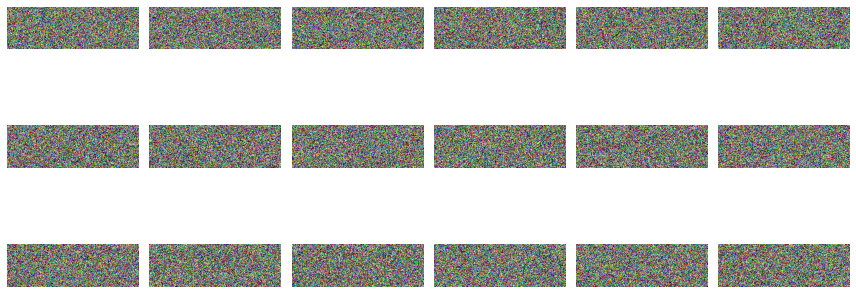

In [15]:
"""
Loading the saved model
"""
#model = DiffusionModel(image_size, widths, block_depth)
#model.normalizer.adapt(train_dataset) # need this in order for it not to produce any error
model.load_weights(checkpoint_path)
model.plot_images()

In [ ]:
model.save(f'{folder_path}/my_model.keras')

In [ ]:
"""
SOMETIMES AFTER LOADING THE WEIGHTS 
ONTO THE MODEL, SOMETIMES IT DOES NOT 
GENERATE FLOWERS (PROBABLY OVERFITTING), 
AND TRAINING IT FOR A COUPLE GENERATION 
HELPS WITH RECOVERING BEHAVIOR

num_epochs = 5
model.fit(
    train_dataset,
    epochs=num_epochs,
    validation_data=val_dataset,
    callbacks=[
        keras.callbacks.LambdaCallback(on_epoch_end=model.plot_images), # plot images as well
        checkpoint_callback, # checkpoint callback located here
    ],
)

"""

In [ ]:
print(history.history.keys())

In [ ]:
""" Plotting functions for History """

def plot_history(dict_key): 
    plt.plot(history.history[dict_key]) 
    plt.title(dict_key) 
    plt.ylabel(dict_key)
    plt.xlabel("epoch")
    plt.legend(["train"], loc="upper left")
    plt.show()


In [ ]:
plt.figure(1)
plot_history("i_loss")

plt.figure(2)
plot_history("n_loss")

plt.figure(3)
plot_history("val_i_loss")

plt.figure(4)
plot_history("val_kid")

plt.figure(5)
plot_history("val_n_loss")

## Results

By running the training for at least 50 epochs (takes 2 hours on a T4 GPU and 30 minutes
on an A100 GPU), one can get high quality image generations using this code example.

The evolution of a batch of images over a 80 epoch training (color artifacts are due to
GIF compression):

![flowers training gif](https://i.imgur.com/FSCKtZq.gif)

Images generated using between 1 and 20 sampling steps from the same initial noise:

![flowers sampling steps gif](https://i.imgur.com/tM5LyH3.gif)

Interpolation (spherical) between initial noise samples:

![flowers interpolation gif](https://i.imgur.com/hk5Hd5o.gif)

Deterministic sampling process (noisy images on top, predicted images on bottom, 40
steps):

![flowers deterministic generation gif](https://i.imgur.com/wCvzynh.gif)

Stochastic sampling process (noisy images on top, predicted images on bottom, 80 steps):

![flowers stochastic generation gif](https://i.imgur.com/kRXOGzd.gif)

## Lessons learned

During preparation for this code example I have run numerous experiments using
[this repository](https://github.com/beresandras/clear-diffusion-keras).
In this section I list
the lessons learned and my recommendations in my subjective order of importance.

### Algorithmic tips

* **min. and max. signal rates**: I found the min. signal rate to be an important
hyperparameter. Setting it too low will make the generated images oversaturated, while
setting it too high will make them undersaturated. I recommend tuning it carefully. Also,
setting it to 0 will lead to a division by zero error. The max. signal rate can be set to
1, but I found that setting it lower slightly improves generation quality.
* **loss function**: While large models tend to use mean squared error (MSE) loss, I
recommend using mean absolute error (MAE) on this dataset. In my experience MSE loss
generates more diverse samples (it also seems to hallucinate more
[Section 3](https://arxiv.org/abs/2111.05826)), while MAE loss leads to smoother images.
I recommend trying both.
* **weight decay**: I did occasionally run into diverged trainings when scaling up the
model, and found that weight decay helps in avoiding instabilities at a low performance
cost. This is why I use
[AdamW](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/experimental/AdamW)
instead of [Adam](https://keras.io/api/optimizers/adam/) in this example.
* **exponential moving average of weights**: This helps to reduce the variance of the KID
metric, and helps in averaging out short-term changes during training.
* **image augmentations**: Though I did not use image augmentations in this example, in
my experience adding horizontal flips to the training increases generation performance,
while random crops do not. Since we use a supervised denoising loss, overfitting can be
an issue, so image augmentations might be important on small datasets. One should also be
careful not to use
[leaky augmentations](https://keras.io/examples/generative/gan_ada/#invertible-data-augmentation),
which can be done following
[this method (end of Section 5)](https://arxiv.org/abs/2206.00364) for instance.
* **data normalization**: In the literature the pixel values of images are usually
converted to the -1 to 1 range. For theoretical correctness, I normalize the images to
have zero mean and unit variance instead, exactly like the random noises.
* **noise level input**: I chose to input the noise variance to the network, as it is
symmetrical under our sampling schedule. One could also input the noise rate (similar
performance), the signal rate (lower performance), or even the
[log-signal-to-noise ratio (Appendix B.1)](https://arxiv.org/abs/2107.00630)
(did not try, as its range is highly
dependent on the min. and max. signal rates, and would require adjusting the min.
embedding frequency accordingly).
* **gradient clipping**: Using global gradient clipping with a value of 1 can help with
training stability for large models, but decreased performance significantly in my
experience.
* **residual connection downscaling**: For
[deeper models (Appendix B)](https://arxiv.org/abs/2205.11487), scaling the residual
connections with 1/sqrt(2) can be helpful, but did not help in my case.
* **learning rate**: For me, [Adam optimizer's](https://keras.io/api/optimizers/adam/)
default learning rate of 1e-3 worked very well, but lower learning rates are more common
in the [literature (Tables 11-13)](https://arxiv.org/abs/2105.05233).

### Architectural tips

* **sinusoidal embedding**: Using sinusoidal embeddings on the noise level input of the
network is crucial for good performance. I recommend setting the min. embedding frequency
to the reciprocal of the range of this input, and since we use the noise variance in this
example, it can be left always at 1. The max. embedding frequency controls the smallest
change in the noise variance that the network will be sensitive to, and the embedding
dimensions set the number of frequency components in the embedding. In my experience the
performance is not too sensitive to these values.
* **skip connections**: Using skip connections in the network architecture is absolutely
critical, without them the model will fail to learn to denoise at a good performance.
* **residual connections**: In my experience residual connections also significantly
improve performance, but this might be due to the fact that we only input the noise
level embeddings to the first layer of the network instead of to all of them.
* **normalization**: When scaling up the model, I did occasionally encounter diverged
trainings, using normalization layers helped to mitigate this issue. In the literature it
is common to use
[GroupNormalization](https://www.tensorflow.org/addons/api_docs/python/tfa/layers/GroupNormalization)
(with 8 groups for example) or
[LayerNormalization](https://keras.io/api/layers/normalization_layers/layer_normalization/)
in the network, I however chose to use
[BatchNormalization](https://keras.io/api/layers/normalization_layers/batch_normalization/),
as it gave similar benefits in my experiments but was computationally lighter.
* **activations**: The choice of activation functions had a larger effect on generation
quality than I expected. In my experiments using non-monotonic activation functions
outperformed monotonic ones (such as
[ReLU](https://www.tensorflow.org/api_docs/python/tf/keras/activations/relu)), with
[Swish](https://www.tensorflow.org/api_docs/python/tf/keras/activations/swish) performing
the best (this is also what [Imagen uses, page 41](https://arxiv.org/abs/2205.11487)).
* **attention**: As mentioned earlier, it is common in the literature to use
[attention layers](https://keras.io/api/layers/attention_layers/multi_head_attention/) at low
resolutions for better global coherence. I omitted them for simplicity.
* **upsampling**:
[Bilinear and nearest neighbour upsampling](https://keras.io/api/layers/reshaping_layers/up_sampling2d/)
in the network performed similarly, however I did not try
[transposed convolutions](https://keras.io/api/layers/convolution_layers/convolution2d_transpose/).

For a similar list about GANs check out
[this Keras tutorial](https://keras.io/examples/generative/gan_ada/#gan-tips-and-tricks).

## What to try next?

If you would like to dive in deeper to the topic, I recommend checking out
[this repository](https://github.com/beresandras/clear-diffusion-keras) that I created in
preparation for this code example, which implements a wider range of features in a
similar style, such as:

* stochastic sampling
* second-order sampling based on the
[differential equation view of DDIMs (Equation 13)](https://arxiv.org/abs/2010.02502)
* more diffusion schedules
* more network output types: predicting image or
[velocity (Appendix D)](https://arxiv.org/abs/2202.00512) instead of noise
* more datasets

## Related works

* [Score-based generative modeling](https://yang-song.github.io/blog/2021/score/)
(blogpost)
* [What are diffusion models?](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)
(blogpost)
* [Annotated diffusion model](https://huggingface.co/blog/annotated-diffusion) (blogpost)
* [CVPR 2022 tutorial on diffusion models](https://cvpr2022-tutorial-diffusion-models.github.io/)
(slides available)
* [Elucidating the Design Space of Diffusion-Based Generative Models](https://arxiv.org/abs/2206.00364):
attempts unifying diffusion methods under a common framework
* High-level video overviews: [1](https://www.youtube.com/watch?v=yTAMrHVG1ew),
[2](https://www.youtube.com/watch?v=344w5h24-h8)
* Detailed technical videos: [1](https://www.youtube.com/watch?v=fbLgFrlTnGU),
[2](https://www.youtube.com/watch?v=W-O7AZNzbzQ)
* Score-based generative models: [NCSN](https://arxiv.org/abs/1907.05600),
[NCSN+](https://arxiv.org/abs/2006.09011), [NCSN++](https://arxiv.org/abs/2011.13456)
* Denoising diffusion models: [DDPM](https://arxiv.org/abs/2006.11239),
[DDIM](https://arxiv.org/abs/2010.02502), [DDPM+](https://arxiv.org/abs/2102.09672),
[DDPM++](https://arxiv.org/abs/2105.05233)
* Large diffusion models: [GLIDE](https://arxiv.org/abs/2112.10741),
[DALL-E 2](https://arxiv.org/abs/2204.06125/), [Imagen](https://arxiv.org/abs/2205.11487)
